# Variational Autoencoders for Atmospheric State Compression

## Motivation

In the matrix decomposition module we used SVD/PCA to compress atmospheric fields into a small set of leading patterns (EOFs). That compression is *linear* — the latent representation is a weighted sum of fixed spatial modes. Real atmospheric variability is deeply nonlinear: fronts, jet streams, and convective systems don't live in a flat subspace.

Neural networks can learn *nonlinear* encoder-decoder pairs that compress and reconstruct data far more efficiently than PCA for the same latent dimension. But a purely deterministic autoencoder has an unstructured latent space — you can't sample from it meaningfully. **Variational autoencoders (VAEs)** add a probabilistic constraint that regularises the latent space into a smooth, sampleable Gaussian, enabling generation of new atmospheric states.

## What we'll cover

1. **Data setup** — GFS analysis fields over CONUS (5 variables, 1° resolution, 1 year)
2. **Baseline: PCA** — linear compression for comparison
3. **Deterministic MLP autoencoder** — nonlinear compression, unstructured latent space
4. **MLP-VAE** — add the variational objective (ELBO derivation)
5. **Conv-VAE** — spatially-aware encoder/decoder, building on the ConvNet module
6. **Head-to-head comparison** — reconstruction quality, generation, latent structure
7. **Latent space analysis** — do the learned codes capture meteorological regimes?
8. **Generation & interpolation** — sample new states, blend between real ones
9. **The blurriness problem** — why VAEs struggle with fine-scale structure (→ diffusion models)

## Earth science connection

Latent representations of atmospheric states are useful beyond reconstruction: they can seed ensemble forecasts, drive anomaly detection, or serve as compact state vectors for data assimilation. The blurriness limitation we expose at the end directly motivates the score-based diffusion models in the next module.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

rng = np.random.default_rng(42)
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 1. Data Loading

We use GFS analysis fields from [dynamical.org](https://dynamical.org) — the same dataset used in the ConvNet forecasting notebook. We take 5 variables over CONUS at 1° resolution (strided from the native 0.25°), giving a 36×71 spatial grid per snapshot.

In [37]:
VARIABLES = [
    'temperature_2m',
    'pressure_reduced_to_mean_sea_level',
    'precipitable_water_atmosphere',
    'wind_u_10m',
    'wind_v_10m',
]

LAT_NORTH, LAT_SOUTH = 55.0, 20.0
LON_WEST, LON_EAST   = -130.0, -60.0
SPATIAL_STRIDE       = 4        # 0.25° × 4 = 1° resolution
TIME_STRIDE_HOURS    = 6        # one snapshot every 6 hours
LATENT_DIM           = 32

ds = xr.open_zarr(
    'https://data.dynamical.org/noaa/gfs/analysis/latest.zarr'
)[VARIABLES]

ds = ds.sel(
    time=slice('2021-01-01', '2023-12-31'),
    latitude=slice(LAT_NORTH, LAT_SOUTH),
    longitude=slice(LON_WEST, LON_EAST),
).isel(
    time=slice(None, None, TIME_STRIDE_HOURS),
    latitude=slice(None, None, SPATIAL_STRIDE),
    longitude=slice(None, None, SPATIAL_STRIDE),
)

print('Loading data...')
data = np.stack([ds[v].values for v in VARIABLES], axis=1).astype(np.float32)
# data shape: (T, C, H, W)  =  (time, variables, lat, lon)
print(f'Data shape: {data.shape}   →  (T={data.shape[0]}, C={data.shape[1]}, H={data.shape[2]}, W={data.shape[3]})')

Loading data...
Data shape: (3900, 5, 36, 71)   →  (T=3900, C=5, H=36, W=71)


In [38]:
# Train/val split (temporal — no shuffle)
T = data.shape[0]
n_train = int(0.8 * T)
train_data, val_data = data[:n_train], data[n_train:]

# Per-variable normalisation using training statistics only
train_mean = train_data.mean(axis=(0, 2, 3), keepdims=True)  # (1, C, 1, 1)
train_std  = train_data.std(axis=(0, 2, 3), keepdims=True) + 1e-6

train_norm = (train_data - train_mean) / train_std
val_norm   = (val_data   - train_mean) / train_std

C, H, W = data.shape[1], data.shape[2], data.shape[3]
print(f'Train: {train_norm.shape}   Val: {val_norm.shape}')
print(f'Spatial grid: {H}×{W},  Variables: {C},  Latent dim: {LATENT_DIM}')

# PyTorch datasets
train_tensor = torch.tensor(train_norm)
val_tensor   = torch.tensor(val_norm)
train_loader = DataLoader(TensorDataset(train_tensor), batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(val_tensor),   batch_size=64)

Train: (3120, 5, 36, 71)   Val: (780, 5, 36, 71)
Spatial grid: 36×71,  Variables: 5,  Latent dim: 32


## 2. Baseline PCA

We start with the tool you already know. PCA projects each flattened snapshot onto the $k$ directions of maximum variance:

$$\mathbf{x} \approx \boldsymbol{\mu} + \mathbf{U}_k \mathbf{z}, \qquad \mathbf{z} = \mathbf{U}_k^\top (\mathbf{x} - \boldsymbol{\mu})$$

With $k = 32$ components this gives our baseline reconstruction quality. We'll use this as the benchmark for every model that follows.

In [39]:
X_train_flat = train_norm.reshape(n_train, -1)   # (T_train, C*H*W)
X_val_flat   = val_norm.reshape(T - n_train, -1)

pca = PCA(n_components=LATENT_DIM, random_state=42)
pca.fit(X_train_flat)

# Encode then decode validation set
z_pca_val  = pca.transform(X_val_flat)
recon_pca  = pca.inverse_transform(z_pca_val).reshape(T - n_train, C, H, W)

pca_mse = np.mean((recon_pca - val_norm) ** 2)
print(f'PCA reconstruction MSE (val): {pca_mse:.4f}')
print(f'Explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%')

PCA reconstruction MSE (val): 0.1539
Explained variance: 80.9%


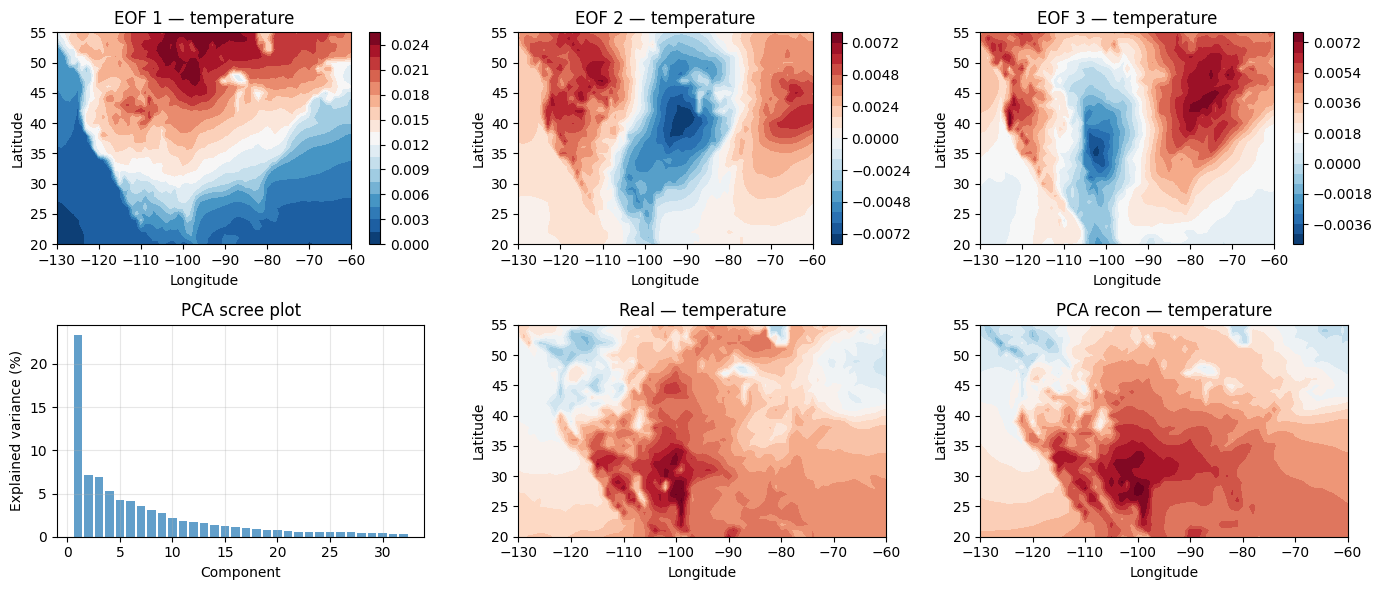

In [40]:
lats = ds.latitude.values
lons = ds.longitude.values

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
titles = ['EOF 1', 'EOF 2', 'EOF 3']
for i, ax in enumerate(axes[0]):
    eof = pca.components_[i].reshape(C, H, W)[0]  # temperature component
    im = ax.contourf(lons, lats, eof, levels=20, cmap='RdBu_r')
    ax.set_title(f'{titles[i]} — temperature')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    plt.colorbar(im, ax=ax)

# Scree plot
ax = axes[1, 0]
ax.bar(range(1, LATENT_DIM + 1), pca.explained_variance_ratio_ * 100, alpha=0.7)
ax.set_xlabel('Component')
ax.set_ylabel('Explained variance (%)')
ax.set_title('PCA scree plot')
ax.grid(alpha=0.3)

# Real vs PCA reconstruction
idx = 0
for col, (title, field) in enumerate([
    ('Real', val_norm[idx, 0]),
    ('PCA recon', recon_pca[idx, 0]),
]):
    ax = axes[1, col + 1]
    vmax = np.abs(field).max()
    ax.contourf(lons, lats, field, levels=20, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_title(f'{title} — temperature')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.tight_layout()
plt.show()

## 3. Deterministic MLP Autoencoder

We replace the linear PCA projection with a pair of MLPs:

- **Encoder** $f_\phi$: flattened snapshot $\mathbf{x} \in \mathbb{R}^{C \cdot H \cdot W}$ → latent code $\mathbf{z} \in \mathbb{R}^{32}$
- **Decoder** $g_\theta$: latent code $\mathbf{z}$ → reconstruction $\hat{\mathbf{x}}$

Trained to minimise MSE reconstruction loss: $\mathcal{L} = \|\mathbf{x} - g_\theta(f_\phi(\mathbf{x}))\|^2$

The key question: does the latent space have any structure we can exploit?

In [41]:
class MLPEncoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512), nn.ReLU(),
            nn.Linear(512, 256),       nn.ReLU(),
            nn.Linear(256, latent_dim),
        )

    def forward(self, x):
        return self.net(x.flatten(1))


class MLPDecoder(nn.Module):
    def __init__(self, latent_dim, output_dim, output_shape):
        super().__init__()
        self.output_shape = output_shape
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.ReLU(),
            nn.Linear(256, 512),        nn.ReLU(),
            nn.Linear(512, output_dim),
        )

    def forward(self, z):
        return self.net(z).view(-1, *self.output_shape)


class MLPAE(nn.Module):
    def __init__(self, c, h, w, latent_dim):
        super().__init__()
        self.encoder = MLPEncoder(c * h * w, latent_dim)
        self.decoder = MLPDecoder(latent_dim, c * h * w, (c, h, w))

    def forward(self, x):
        return self.decoder(self.encoder(x))

    def encode(self, x):
        return self.encoder(x)


mlp_ae = MLPAE(C, H, W, LATENT_DIM).to(device)
print(f'MLP-AE parameters: {sum(p.numel() for p in mlp_ae.parameters()):,}')

MLP-AE parameters: 13,379,596


In [42]:
def train_ae(model, train_loader, val_loader, n_epochs=30, lr=1e-3):
    """Generic training loop for deterministic autoencoders."""
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    train_losses, val_losses = [], []

    for epoch in range(n_epochs):
        model.train()
        batch_losses = []
        for (x,) in train_loader:
            x = x.to(device)
            loss = F.mse_loss(model(x), x)
            opt.zero_grad()
            loss.backward()
            opt.step()
            batch_losses.append(loss.item())
        train_losses.append(np.mean(batch_losses))

        model.eval()
        with torch.no_grad():
            val_loss = np.mean([
                F.mse_loss(model(x.to(device)), x.to(device)).item()
                for (x,) in val_loader
            ])
        val_losses.append(val_loss)

        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1:3d} | train {train_losses[-1]:.4f} | val {val_losses[-1]:.4f}')

    return train_losses, val_losses


print('Training MLP autoencoder...')
ae_train_loss, ae_val_loss = train_ae(mlp_ae, train_loader, val_loader, n_epochs=40)

Training MLP autoencoder...
Epoch  10 | train 0.1458 | val 0.1867
Epoch  20 | train 0.1120 | val 0.1809
Epoch  30 | train 0.0966 | val 0.1878
Epoch  40 | train 0.0873 | val 0.1966


MLP-AE reconstruction MSE (val): 0.1962  (PCA baseline: 0.1539)


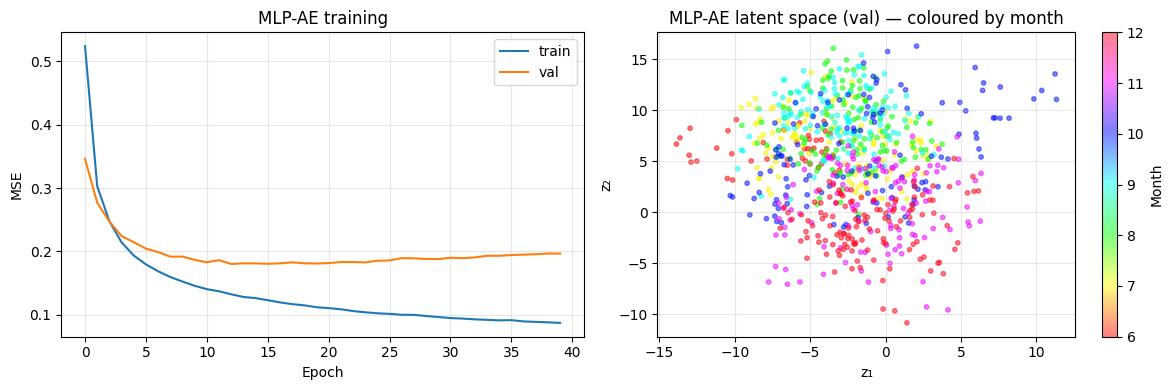

Observation: latent codes are scattered with no density. Sampling a random z → garbage.


In [43]:
# Encode the full validation set and look at latent space structure
mlp_ae.eval()
with torch.no_grad():
    z_ae_val = mlp_ae.encode(val_tensor.to(device)).cpu().numpy()
    recon_ae = mlp_ae(val_tensor.to(device)).cpu().numpy()

ae_mse = np.mean((recon_ae - val_norm) ** 2)
print(f'MLP-AE reconstruction MSE (val): {ae_mse:.4f}  (PCA baseline: {pca_mse:.4f})')

# Month labels for colour coding (val set starts at month index n_train // (24//TIME_STRIDE_HOURS * 30))
# Build a time array for the validation slice
import pandas as pd
times = pd.DatetimeIndex(ds.time.values)
val_months = times[n_train:].month.tolist()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(ae_train_loss, label='train')
axes[0].plot(ae_val_loss,   label='val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].set_title('MLP-AE training')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2D projection of latent space (first two dimensions)
sc = axes[1].scatter(z_ae_val[:, 0], z_ae_val[:, 1], c=val_months,
                     cmap='hsv', alpha=0.5, s=10)
plt.colorbar(sc, ax=axes[1], label='Month')
axes[1].set_xlabel('z₁')
axes[1].set_ylabel('z₂')
axes[1].set_title('MLP-AE latent space (val) — coloured by month')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print('Observation: latent codes are scattered with no density. Sampling a random z → garbage.')

## 4. MLP Variational Autoencoder

### The problem with a deterministic latent space

The MLP-AE latent codes are irregular: there are voids between clusters where no training data lives. Decoding a random point from one of those voids produces garbage. We need a way to *regularise* the latent space so it behaves like a proper probability distribution.

### The variational idea

Instead of encoding to a point, encode to a **distribution**:

$$q_\phi(\mathbf{z} \mid \mathbf{x}) = \mathcal{N}\bigl(\boldsymbol{\mu}_\phi(\mathbf{x}),\; \text{diag}(\boldsymbol{\sigma}^2_\phi(\mathbf{x}))\bigr)$$

The encoder outputs $\boldsymbol{\mu}$ and $\log \boldsymbol{\sigma}^2$ (we parameterise the log-variance for numerical stability). We then *sample* $\mathbf{z}$ from this distribution before decoding.

### The ELBO objective

We want the encoder posterior $q_\phi(\mathbf{z}|\mathbf{x})$ to be close to a standard Gaussian prior $p(\mathbf{z}) = \mathcal{N}(\mathbf{0}, \mathbf{I})$. The **evidence lower bound (ELBO)** is:

$$\mathcal{L}_{\text{ELBO}} = \underbrace{\mathbb{E}_{q_\phi}\bigl[\log p_\theta(\mathbf{x} \mid \mathbf{z})\bigr]}_{\text{reconstruction}} - \underbrace{D_{\text{KL}}\bigl(q_\phi(\mathbf{z}|\mathbf{x}) \,\|\, p(\mathbf{z})\bigr)}_{\text{regularisation}}$$

For a Gaussian decoder (MSE) and diagonal Gaussian posterior, both terms have closed forms:

$$\mathcal{L} = \|\mathbf{x} - \hat{\mathbf{x}}\|^2 + \frac{1}{2}\sum_{j=1}^{d}\bigl(\mu_j^2 + \sigma_j^2 - \log \sigma_j^2 - 1\bigr)$$

The KL term penalises encoders that stray far from the unit Gaussian, pushing all codes toward the origin and filling the latent space.

### The reparameterisation trick

We cannot backpropagate through a *sample* $\mathbf{z} \sim q_\phi$. The trick is to write the sample as a deterministic function of the parameters and a fixed noise source:

$$\mathbf{z} = \boldsymbol{\mu} + \boldsymbol{\sigma} \odot \boldsymbol{\epsilon}, \qquad \boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$$

Gradients flow through $\boldsymbol{\mu}$ and $\boldsymbol{\sigma}$ normally; $\boldsymbol{\epsilon}$ is treated as a constant.

In [44]:
class MLPVAE(nn.Module):
    def __init__(self, c, h, w, latent_dim):
        super().__init__()
        input_dim = c * h * w
        self.output_shape = (c, h, w)

        # Shared encoder trunk
        self.encoder_trunk = nn.Sequential(
            nn.Linear(input_dim, 512), nn.ReLU(),
            nn.Linear(512, 256),       nn.ReLU(),
        )
        # Two heads: mean and log-variance
        self.fc_mu     = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.ReLU(),
            nn.Linear(256, 512),        nn.ReLU(),
            nn.Linear(512, input_dim),
        )

    def encode(self, x):
        h = self.encoder_trunk(x.flatten(1))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterise(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def decode(self, z):
        return self.decoder(z).view(-1, *self.output_shape)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterise(mu, logvar)
        return self.decode(z), mu, logvar


def elbo_loss(recon_x, x, mu, logvar, beta=1.0):
    """ELBO = reconstruction MSE + beta * KL divergence."""
    recon_loss = F.mse_loss(recon_x, x, reduction='mean')
    # KL per dimension: 0.5 * (mu^2 + sigma^2 - log sigma^2 - 1)
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl, recon_loss.item(), kl.item()


mlp_vae = MLPVAE(C, H, W, LATENT_DIM).to(device)
print(f'MLP-VAE parameters: {sum(p.numel() for p in mlp_vae.parameters()):,}')

MLP-VAE parameters: 13,387,820


In [45]:
def train_vae(model, train_loader, val_loader, n_epochs=40, lr=1e-3, beta=1.0):
    """Training loop for VAEs; returns loss history including KL term."""
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    history = {'train_total': [], 'train_recon': [], 'train_kl': [], 'val_total': []}

    for epoch in range(n_epochs):
        model.train()
        totals, recons, kls = [], [], []
        for (x,) in train_loader:
            x = x.to(device)
            recon_x, mu, logvar = model(x)
            loss, r, k = elbo_loss(recon_x, x, mu, logvar, beta=beta)
            opt.zero_grad()
            loss.backward()
            opt.step()
            totals.append(loss.item())
            recons.append(r)
            kls.append(k)
        history['train_total'].append(np.mean(totals))
        history['train_recon'].append(np.mean(recons))
        history['train_kl'].append(np.mean(kls))

        model.eval()
        with torch.no_grad():
            val_losses = []
            for (xv,) in val_loader:
                xv = xv.to(device)
                recon_xv, muv, logvarv = model(xv)
                lv, _, _ = elbo_loss(recon_xv, xv, muv, logvarv, beta=beta)
                val_losses.append(lv.item())
        history['val_total'].append(np.mean(val_losses))

        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1:3d} | total {history["train_total"][-1]:.4f} '
                  f'| recon {history["train_recon"][-1]:.4f} '
                  f'| kl {history["train_kl"][-1]:.4f}')
    return history


print('Training MLP-VAE...')
mlp_vae_history = train_vae(mlp_vae, train_loader, val_loader, n_epochs=40)

Training MLP-VAE...
Epoch  10 | total 0.7258 | recon 0.7258 | kl 0.0000
Epoch  20 | total 0.7237 | recon 0.7237 | kl 0.0000
Epoch  30 | total 0.7240 | recon 0.7240 | kl 0.0000
Epoch  40 | total 0.7232 | recon 0.7231 | kl 0.0000


MLP-VAE reconstruction MSE (val): 0.6777


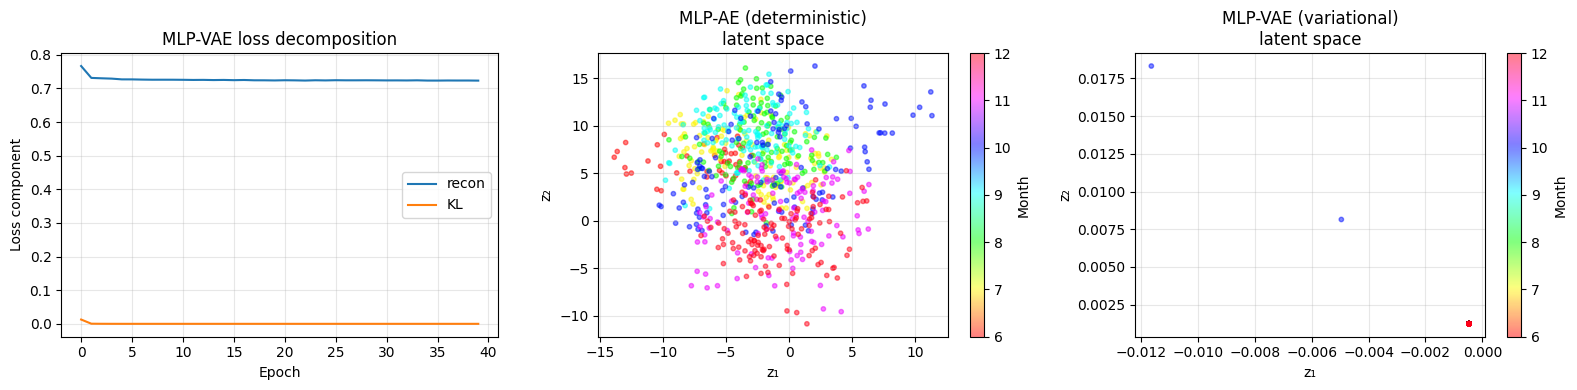

In [46]:
mlp_vae.eval()
with torch.no_grad():
    recon_mlp_vae_t, mu_val, _ = mlp_vae(val_tensor.to(device))
    recon_mlp_vae = recon_mlp_vae_t.cpu().numpy()
    z_mlp_vae_val = mu_val.cpu().numpy()  # use mean as deterministic code

mlp_vae_mse = np.mean((recon_mlp_vae - val_norm) ** 2)
print(f'MLP-VAE reconstruction MSE (val): {mlp_vae_mse:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(mlp_vae_history['train_recon'], label='recon')
axes[0].plot(mlp_vae_history['train_kl'],    label='KL')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss component')
axes[0].set_title('MLP-VAE loss decomposition')
axes[0].legend()
axes[0].grid(alpha=0.3)

for ax, (z, title) in zip(axes[1:], [
    (z_ae_val,       'MLP-AE (deterministic)'),
    (z_mlp_vae_val,  'MLP-VAE (variational)'),
]):
    sc = ax.scatter(z[:, 0], z[:, 1], c=val_months, cmap='hsv', alpha=0.5, s=10)
    plt.colorbar(sc, ax=ax, label='Month')
    ax.set_xlabel('z₁')
    ax.set_ylabel('z₂')
    ax.set_title(f'{title}\nlatent space')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Convolutional VAE

The MLP encoder flattens the spatial field before processing it, discarding all spatial structure. A **convolutional encoder** instead applies strided convolutions that progressively downsample the field while extracting local features — the same inductive bias we used for forecasting.

**Encoder**: $(C, H, W) \xrightarrow{\text{conv stride 2}} (32, H/2, W/2) \xrightarrow{\text{conv stride 2}} (64, H/4, W/4) \xrightarrow{\text{flatten+linear}} (\mu, \log\sigma^2)$

**Decoder**: $\mathbf{z} \xrightarrow{\text{linear+unflatten}} (64, H/4, W/4) \xrightarrow{\text{bilinear}} (32, H/2, W/2) \xrightarrow{\text{bilinear}} (C, H, W)$

The ELBO loss is identical to before — only the architecture changes.

In [47]:
class ConvVAEEncoder(nn.Module):
    def __init__(self, in_channels, latent_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),          nn.ReLU(),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, in_channels, H, W)
            flat_dim = self.conv(dummy).flatten(1).shape[1]
        self.flat_dim = flat_dim
        self.fc_mu     = nn.Linear(flat_dim, latent_dim)
        self.fc_logvar = nn.Linear(flat_dim, latent_dim)

    def forward(self, x):
        h = self.conv(x).flatten(1)
        return self.fc_mu(h), self.fc_logvar(h)


class ConvVAEDecoder(nn.Module):
    """Upsample-then-conv decoder to avoid ConvTranspose2d checkerboard artifacts."""
    def __init__(self, latent_dim, out_channels, spatial_shape, flat_dim, target_shape):
        super().__init__()
        self.spatial_shape = spatial_shape
        self.target_h, self.target_w = target_shape
        self.fc = nn.Linear(latent_dim, flat_dim)
        # Two upsample + conv blocks instead of ConvTranspose2d
        self.up1 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(64, 32, 3, padding=1), nn.ReLU(),
        )
        self.up2 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(32, out_channels, 3, padding=1),
        )

    def forward(self, z):
        h = self.fc(z).view(z.shape[0], 64, *self.spatial_shape)
        h = self.up1(h)
        h = self.up2(h)
        # Crop or pad to exact target size
        return h[:, :, :self.target_h, :self.target_w]


class ConvVAE(nn.Module):
    def __init__(self, c, h, w, latent_dim):
        super().__init__()
        self.encoder = ConvVAEEncoder(c, latent_dim)
        bh = (h + 1) // 2
        bh = (bh + 1) // 2
        bw = (w + 1) // 2
        bw = (bw + 1) // 2
        self.decoder = ConvVAEDecoder(latent_dim, c, (bh, bw), self.encoder.flat_dim, (h, w))

    def reparameterise(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterise(mu, logvar)
        return self.decoder(z), mu, logvar

    def encode(self, x):
        return self.encoder(x)[0]

    def decode(self, z, target_shape=None):
        return self.decoder(z)


conv_vae = ConvVAE(C, H, W, LATENT_DIM).to(device)
print(f'Conv-VAE parameters: {sum(p.numel() for p in conv_vae.parameters()):,}')

with torch.no_grad():
    dummy = torch.zeros(2, C, H, W).to(device)
    out, mu, lv = conv_vae(dummy)
    print(f'Input: {dummy.shape}  →  Recon: {out.shape},  z: {mu.shape}')

Conv-VAE parameters: 1,045,637
Input: torch.Size([2, 5, 36, 71])  →  Recon: torch.Size([2, 5, 36, 71]),  z: torch.Size([2, 32])


In [48]:
print('Training Conv-VAE...')
conv_vae_history = train_vae(conv_vae, train_loader, val_loader, n_epochs=40)

conv_vae.eval()
with torch.no_grad():
    recon_conv_vae_t, mu_conv_val, _ = conv_vae(val_tensor.to(device))
    recon_conv_vae = recon_conv_vae_t.cpu().numpy()
    z_conv_vae_val = mu_conv_val.cpu().numpy()

conv_vae_mse = np.mean((recon_conv_vae - val_norm) ** 2)
print(f'Conv-VAE reconstruction MSE (val): {conv_vae_mse:.4f}')

Training Conv-VAE...
Epoch  10 | total 0.5835 | recon 0.4813 | kl 0.1021
Epoch  20 | total 0.5634 | recon 0.4465 | kl 0.1169
Epoch  30 | total 0.5530 | recon 0.4319 | kl 0.1211
Epoch  40 | total 0.5501 | recon 0.4266 | kl 0.1235

Conv-VAE reconstruction MSE (val): 0.4380


## 6. Head-to-Head Comparison

All four models compress to the same 32-dimensional latent space. How do they compare?

In [54]:
models_summary = {
    'PCA':       {'mse': pca_mse,       'recon': recon_pca,      'latent': z_pca_val},
    'MLP-AE':    {'mse': ae_mse,        'recon': recon_ae,       'latent': z_ae_val},
    'MLP-VAE':   {'mse': mlp_vae_mse,   'recon': recon_mlp_vae,  'latent': z_mlp_vae_val},
    'Conv-VAE':  {'mse': conv_vae_mse,  'recon': recon_conv_vae, 'latent': z_conv_vae_val},
}

print('Model             MSE (val)')
print('-' * 30)
for name, d in models_summary.items():
    print(f'{name:<18}  {d["mse"]:.4f}')

Model             MSE (val)
------------------------------
PCA                 0.1539
MLP-AE              0.1962
MLP-VAE             0.6777
Conv-VAE            0.4380


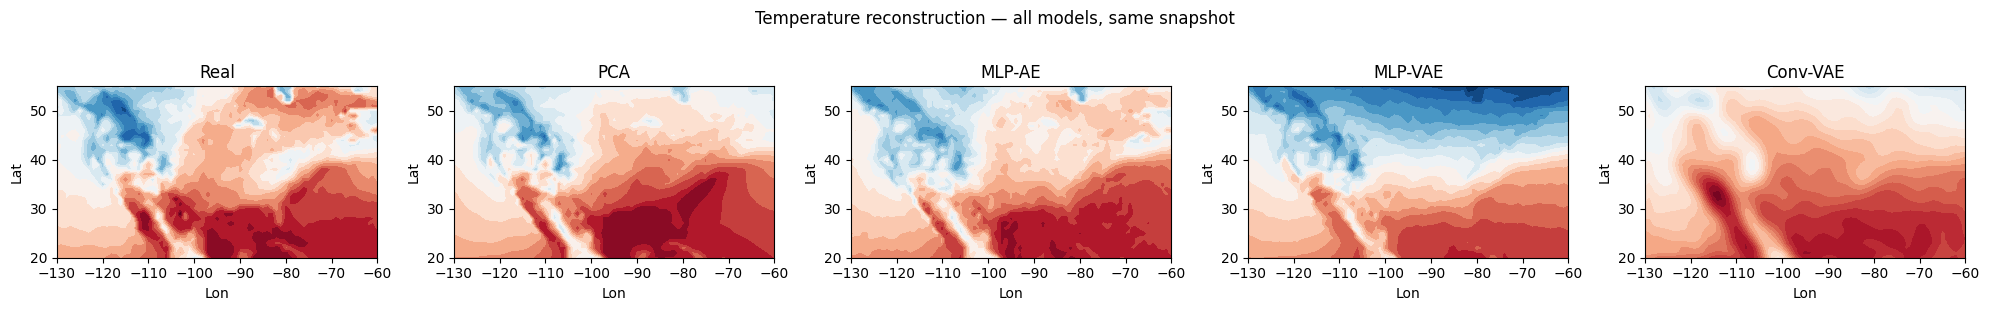

In [55]:
# Visual comparison: one snapshot, temperature channel
idx = 10
real_field = val_norm[idx, 0]

fig, axes = plt.subplots(1, 5, figsize=(20, 3))
vmax = np.abs(real_field).max()
kw = dict(cmap='RdBu_r', vmin=-vmax, vmax=vmax, levels=20)

for ax, (title, field) in zip(axes, [
    ('Real', real_field),
    ('PCA',      models_summary['PCA']['recon'][idx, 0]),
    ('MLP-AE',   models_summary['MLP-AE']['recon'][idx, 0]),
    ('MLP-VAE',  models_summary['MLP-VAE']['recon'][idx, 0]),
    ('Conv-VAE', models_summary['Conv-VAE']['recon'][idx, 0]),
]):
    ax.contourf(lons, lats, field, **kw)
    ax.set_title(title)
    ax.set_xlabel('Lon')
    ax.set_ylabel('Lat')

plt.suptitle('Temperature reconstruction — all models, same snapshot', y=1.02)
plt.tight_layout()
plt.show()

## 7. Latent Space Structure

Do the VAE latent codes organise themselves by meteorological regime? We colour the 32-dimensional latent space (projected to 2D via its first two dimensions) by month and by season.

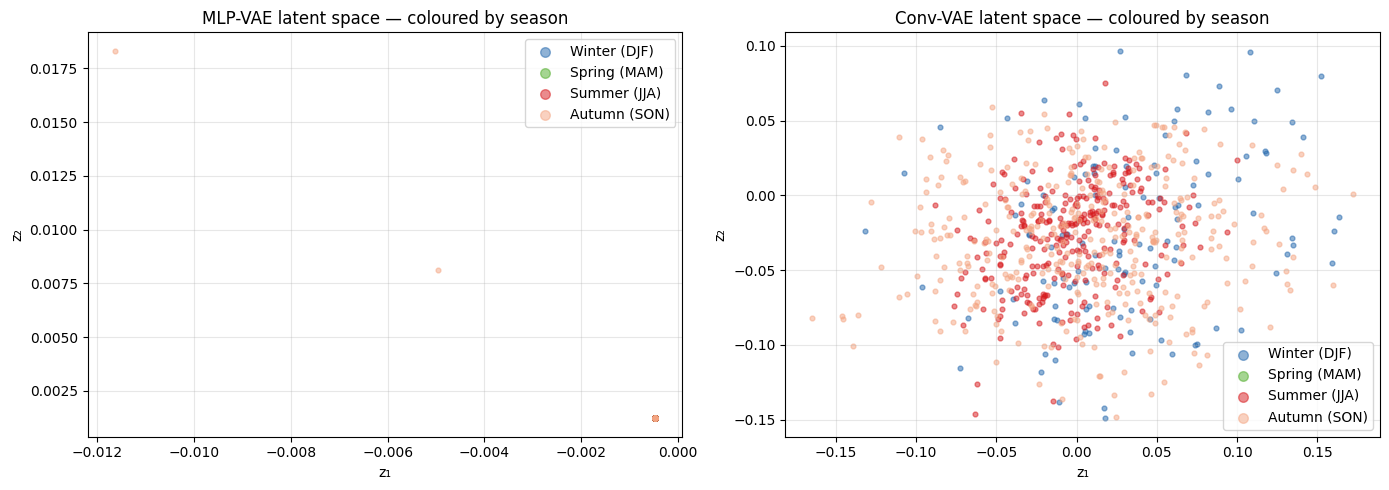

In [56]:
seasons = np.array([
    0 if m in [12, 1, 2] else
    1 if m in [3, 4, 5]  else
    2 if m in [6, 7, 8]  else 3
    for m in val_months
])
season_labels = ['Winter (DJF)', 'Spring (MAM)', 'Summer (JJA)', 'Autumn (SON)']
season_colors = ['#2166ac', '#4dac26', '#d7191c', '#f4a582']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, z) in zip(axes, [
    ('MLP-VAE',  z_mlp_vae_val),
    ('Conv-VAE', z_conv_vae_val),
]):
    for s, (label, color) in enumerate(zip(season_labels, season_colors)):
        mask = seasons == s
        ax.scatter(z[mask, 0], z[mask, 1], c=color, label=label, alpha=0.5, s=12)
    ax.set_xlabel('z₁')
    ax.set_ylabel('z₂')
    ax.set_title(f'{name} latent space — coloured by season')
    ax.legend(markerscale=2)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Generation & Interpolation

Because the VAE latent space is regularised toward $\mathcal{N}(\mathbf{0}, \mathbf{I})$, we can:

1. **Sample** a random $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ and decode it to get a new atmospheric state.
2. **Interpolate** between two real states by blending their latent codes: $\mathbf{z}(\alpha) = (1-\alpha)\mathbf{z}_A + \alpha\mathbf{z}_B$.

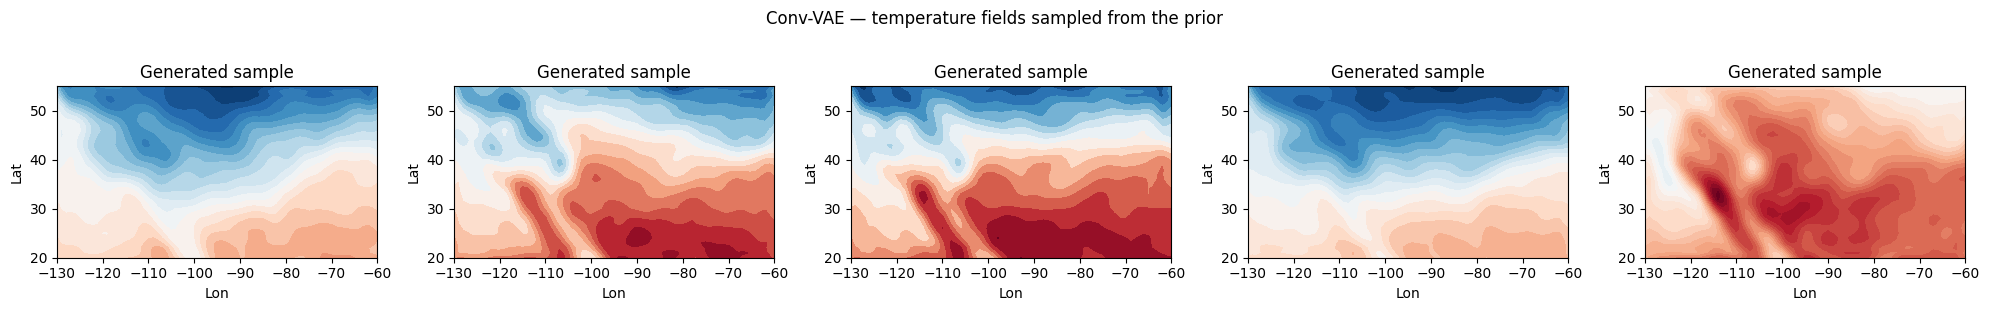

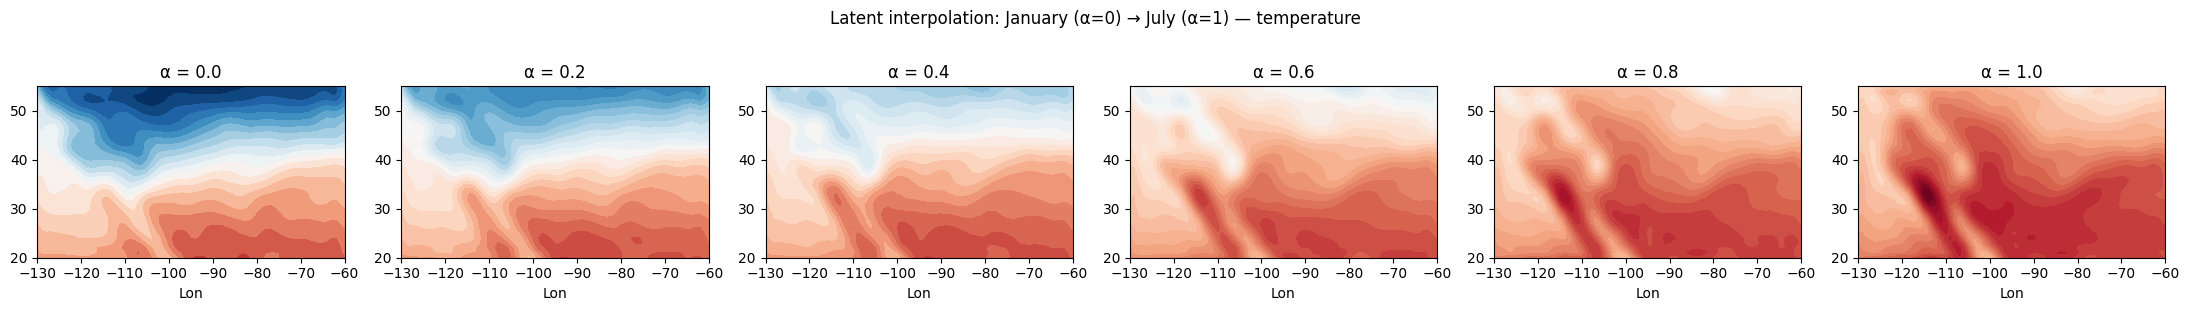

In [57]:
conv_vae.eval()

# --- Generation from prior ---
with torch.no_grad():
    z_sample = torch.randn(5, LATENT_DIM).to(device)
    generated = conv_vae.decode(z_sample, (H, W)).cpu().numpy()

fig, axes = plt.subplots(1, 5, figsize=(20, 3))
for ax, field in zip(axes, generated):
    vmax = np.abs(field[0]).max()
    ax.contourf(lons, lats, field[0], cmap='RdBu_r', vmin=-vmax, vmax=vmax, levels=20)
    ax.set_title('Generated sample')
    ax.set_xlabel('Lon')
    ax.set_ylabel('Lat')
plt.suptitle('Conv-VAE — temperature fields sampled from the prior', y=1.02)
plt.tight_layout()
plt.show()

# --- Latent interpolation ---
with torch.no_grad():
    # Pick a January and a July snapshot from the full dataset
    all_months = pd.DatetimeIndex(ds.time.values).month.tolist()
    jan_idx = next(i for i, m in enumerate(all_months) if m == 1)
    jul_idx = next(i for i, m in enumerate(all_months) if m == 7)
    full_tensor = torch.tensor(np.concatenate([train_norm, val_norm], axis=0))
    z_jan = conv_vae.encode(full_tensor[[jan_idx]].to(device))
    z_jul = conv_vae.encode(full_tensor[[jul_idx]].to(device))

    alphas = np.linspace(0, 1, 6)
    interp_fields = []
    for alpha in alphas:
        z_interp = (1 - alpha) * z_jan + alpha * z_jul
        recon = conv_vae.decode(z_interp, (H, W)).cpu().numpy()
        interp_fields.append(recon[0, 0])

fig, axes = plt.subplots(1, 6, figsize=(22, 3))
vmin = min(f.min() for f in interp_fields)
vmax = max(f.max() for f in interp_fields)
for ax, alpha, field in zip(axes, alphas, interp_fields):
    ax.contourf(lons, lats, field, cmap='RdBu_r', vmin=vmin, vmax=vmax, levels=20)
    ax.set_title(f'α = {alpha:.1f}')
    ax.set_xlabel('Lon')
plt.suptitle('Latent interpolation: January (α=0) → July (α=1) — temperature', y=1.02)
plt.tight_layout()
plt.show()

## 9. The Blurriness Problem

Generated and reconstructed fields look physically plausible at large scales but lack fine-scale structure. This is a fundamental limitation of VAEs trained with MSE reconstruction loss.

**Why?** The MSE loss penalises all spatial frequencies equally. When the model is uncertain about the exact position of a front or trough, it hedges by producing the *average* of possible outcomes — which is spatially smooth. High-frequency content (sharp gradients, narrow features) gets averaged away.

We can quantify this with the **power spectrum**: how much variance the field contains at each spatial scale.

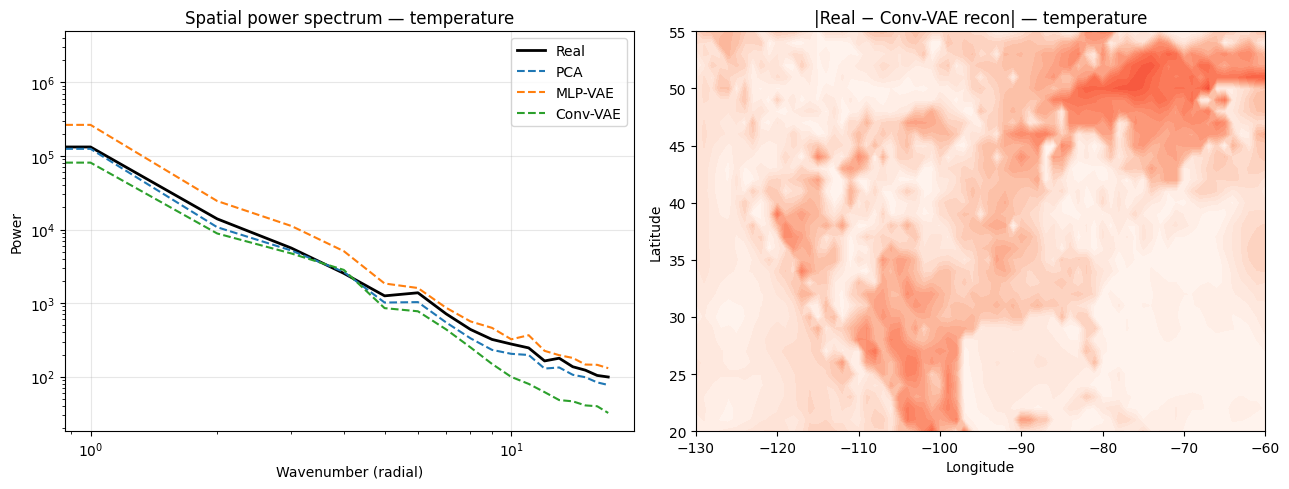


High-frequency deficit in the power spectrum = blurry outputs.
This motivates score-based diffusion models, which learn to add back realistic fine-scale structure.


In [58]:
def radial_power_spectrum(field_stack):
    """Mean radial power spectrum over a stack of 2D fields."""
    spectra = []
    for field in field_stack:
        fft  = np.fft.fft2(field)
        power = np.abs(np.fft.fftshift(fft)) ** 2
        cy, cx = power.shape[0] // 2, power.shape[1] // 2
        y, x = np.ogrid[-cy:power.shape[0]-cy, -cx:power.shape[1]-cx]
        r = np.sqrt(x**2 + y**2).astype(int)
        radial = np.bincount(r.ravel(), power.ravel()) / np.bincount(r.ravel())
        spectra.append(radial[:min(cy, cx)])
    spectra = np.array(spectra)
    return spectra.mean(axis=0)


fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: power spectra comparison
ax = axes[0]
for name, color, recon in [
    ('Real',      'black',   val_norm[:, 0]),
    ('PCA',       'C0',      models_summary['PCA']['recon'][:, 0]),
    ('MLP-VAE',   'C1',      models_summary['MLP-VAE']['recon'][:, 0]),
    ('Conv-VAE',  'C2',      models_summary['Conv-VAE']['recon'][:, 0]),
]:
    ps = radial_power_spectrum(recon[:50])
    ax.loglog(ps, label=name, color=color, lw=2 if name == 'Real' else 1.5,
              ls='-' if name == 'Real' else '--')
ax.set_xlabel('Wavenumber (radial)')
ax.set_ylabel('Power')
ax.set_title('Spatial power spectrum — temperature')
ax.legend()
ax.grid(alpha=0.3)

# Right: difference maps (real minus reconstruction)
ax = axes[1]
idx = 15
diff_mlp  = np.abs(models_summary['MLP-VAE']['recon'][idx, 0]  - val_norm[idx, 0])
diff_conv = np.abs(models_summary['Conv-VAE']['recon'][idx, 0] - val_norm[idx, 0])
vmax = max(diff_mlp.max(), diff_conv.max())
ax.contourf(lons, lats, diff_conv, cmap='Reds', levels=20, vmin=0, vmax=vmax)
ax.set_title('|Real − Conv-VAE recon| — temperature')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.tight_layout()
plt.show()
print('\nHigh-frequency deficit in the power spectrum = blurry outputs.')
print('This motivates score-based diffusion models, which learn to add back realistic fine-scale structure.')